# **불러오기**

In [ ]:
import os, glob, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from scipy.signal import butter, filtfilt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# **파라미터 설정**

In [ ]:

# =========================
# 기본 설정
# =========================
DATA_ROOT = "/content/drive/MyDrive/학교(AI헬스케어)"
SUBJECT_TO_LABEL = {"1":0, "2":0, "3":1, "4":1}  # 20대=0, 50대=1

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

SAVE_DIR = "/content/drive/MyDrive/PPG_MODEL"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# 신호 파라미터
# =========================
FS = 100
BP_LOW, BP_HIGH = 0.5, 5.0
WIN_LEN = 300
HOP = 150

# =========================
# 학습 파라미터 (성능 좋은 기본값)
# =========================
N_WINS_PER_FILE = 128      # 중요
BATCH_FILES = 6
EPOCHS = 1000
LR = 1e-3
WD = 1e-4
DROPOUT = 0.35
CH = 32


# **필터링 등**

In [ ]:
def bandpass_filter(x, fs, low, high, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def parse_sid_from_folder(fp):
    return os.path.basename(os.path.dirname(fp))

def load_ppg_txt(path):
    vals = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                vals.append(int(line.split()[-1]))
            except:
                pass
    x = np.asarray(vals, dtype=np.float32)
    x = bandpass_filter(x, FS, BP_LOW, BP_HIGH)
    return x.astype(np.float32)

def make_windows(x):
    return np.stack([x[i:i+WIN_LEN] for i in range(0, len(x)-WIN_LEN+1, HOP)], axis=0)

def robust_norm(w):
    med = np.median(w)
    mad = np.median(np.abs(w-med)) + 1e-6
    return (w-med)/mad


# **파일 불러오기**

In [ ]:
files = sorted(glob.glob(os.path.join(DATA_ROOT, "*", "*.txt")))
files = [f for f in files if parse_sid_from_folder(f) in SUBJECT_TO_LABEL]

labels = [SUBJECT_TO_LABEL[parse_sid_from_folder(f)] for f in files]

# ⭐ 파일 수 기준 class-weight
class_counts = np.bincount(labels)
class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("File-level class counts:", class_counts)
print("File-level class weights:", class_weights)

def make_fixed_folds(files):
    by_sid = {}
    for fp in files:
        sid = parse_sid_from_folder(fp)
        by_sid.setdefault(sid, []).append(fp)

    # 1~4 폴더가 다 있어야 함
    for sid in ["1","2","3","4"]:
        assert sid in by_sid and len(by_sid[sid]) > 0, f"{sid} 폴더에 txt 없음"

    foldA_train = by_sid["2"] + by_sid["4"]
    foldA_test  = by_sid["1"] + by_sid["3"]
    foldB_train = by_sid["1"] + by_sid["3"]
    foldB_test  = by_sid["2"] + by_sid["4"]
    return [(foldA_train, foldA_test), (foldB_train, foldB_test)]

FOLDS = make_fixed_folds(files)
print("Folds ready:", [(len(tr), len(te)) for tr, te in FOLDS])



File-level class counts: [30 30]
File-level class weights: tensor([1., 1.], device='cuda:0')
Folds ready: [(30, 30), (30, 30)]


In [ ]:
class PPGFileDataset(Dataset):
    def __init__(self, files, train=True):
        self.files = files
        self.train = train

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fp = self.files[idx]
        y = SUBJECT_TO_LABEL[parse_sid_from_folder(fp)]

        raw = load_ppg_txt(fp)
        wins = make_windows(raw)
        wins = np.stack([robust_norm(w) for w in wins], axis=0)

        if len(wins) >= N_WINS_PER_FILE:
            idxs = np.random.choice(len(wins), N_WINS_PER_FILE, replace=False)
        else:
            idxs = np.random.choice(len(wins), N_WINS_PER_FILE, replace=True)

        sel = wins[idxs]

        x = torch.tensor(sel[:, None, :], dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)
        return x, y


In [ ]:
class WindowEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, CH, 9, padding=4),
            nn.BatchNorm1d(CH),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(CH, CH*2, 9, padding=4),
            nn.BatchNorm1d(CH*2),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(CH*2, CH*4, 7, padding=3),
            nn.BatchNorm1d(CH*4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

class FileClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = WindowEncoder()

        # attention scorer: 각 윈도우 임베딩 z_n에 점수 부여
        self.att = nn.Sequential(
            nn.Linear(CH*4, 64),
            nn.Tanh(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, 1)   # score per window
        )

        self.fc = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(CH*4, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # x: (B_files, N_wins, 1, L)
        B, N, C, L = x.shape
        x = x.view(B*N, C, L)

        z = self.enc(x)                 # (B*N, D)
        z = z.view(B, N, -1)            # (B, N, D)

        # attention weights
        a = self.att(z).squeeze(-1)     # (B, N)
        w = torch.softmax(a, dim=1)     # (B, N)

        # weighted pooling
        z_file = (z * w.unsqueeze(-1)).sum(dim=1)  # (B, D)

        return self.fc(z_file)


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(DEVICE)     # (B_files, N_wins, 1, L)
        yb = yb.to(DEVICE)     # (B_files,)

        optimizer.zero_grad()
        logits = model(xb)     # (B_files, 2)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * yb.size(0)

    return total_loss / len(loader.dataset)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import torch

@torch.no_grad()
def eval_file_level(model, loader, verbose=False):
    model.eval()
    y_true, y_pred = [], []

    for batch in loader:
        if len(batch) == 2:
            xb, yb = batch
        else:
            xb, yb, _ = batch

        xb = xb.to(DEVICE)
        logits = model(xb)
        pred = logits.argmax(1).cpu().numpy()

        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.tolist())

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")

    if verbose:
        print("ACC:", acc)
        print("macro-F1:", f1)
        print("Confusion matrix (FILE-level):")
        print(confusion_matrix(y_true, y_pred))
        print(classification_report(
            y_true, y_pred,
            target_names=["20s(0)", "50s(1)"],
            zero_division=0
        ))

    return acc, f1


In [ ]:
def compute_class_weights_from_files(file_list):
    ys = [SUBJECT_TO_LABEL[parse_sid_from_folder(fp)] for fp in file_list]
    counts = np.bincount(ys, minlength=2)
    w = counts.sum() / (2.0 * (counts + 1e-8))
    return torch.tensor(w, dtype=torch.float32).to(DEVICE), counts

In [ ]:
def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5, 5))  # 조금만 키우기

    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # 컬러바 여백 안정화

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title
    )

    # ✅ 회전 제거 + 가운데 정렬
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    # ✅ 셀 테두리(가독성)
    ax.set_xticks(np.arange(cm.shape[1] + 1) - .5, minor=True)
    ax.set_yticks(np.arange(cm.shape[0] + 1) - .5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # 숫자 표시
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12
            )

    # ✅ tight_layout 대신 constrained_layout 느낌으로 여백 직접
    fig.subplots_adjust(left=0.18, right=0.92, top=0.88, bottom=0.18)

    plt.show()


In [ ]:
@torch.no_grad()
def get_file_level_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        pred = logits.argmax(1).cpu().numpy()

        y_true.extend(yb.numpy().tolist())
        y_pred.extend(pred.tolist())

    return y_true, y_pred


# **연령구별**

In [ ]:
fold_accs, fold_f1s = [], []

for fold, (tr_files, te_files) in enumerate(FOLDS, 1):
    print(f"\n==================== FOLD {fold} ====================")

    cw, cnt = compute_class_weights_from_files(tr_files)
    print("train class counts:", cnt, "class weights:", cw.detach().cpu().numpy())

    tr_ds = PPGFileDataset(tr_files, train=True)
    te_ds = PPGFileDataset(te_files, train=False)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_FILES, shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH_FILES, shuffle=False)

    model = FileClassifier().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=cw)   # ⭐ 연령 분류 핵심
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)



==================== FOLD 1 ====================
train class counts: [15 15] class weights: [1. 1.]

==================== FOLD 2 ====================
train class counts: [15 15] class weights: [1. 1.]


In [ ]:
best_f1 = -1
best_state = None
patience, wait = 10, 0

for ep in range(1, EPOCHS + 1):
    train_epoch(model, tr_loader, optimizer, criterion)

    acc, f1 = eval_file_level(model, te_loader, verbose=False)

    if f1 > best_f1:
        best_f1 = f1
        best_state = {k: v.detach().cpu().clone()
                      for k, v in model.state_dict().items()}
        wait = 0
        print(f"[Fold {fold}] ep={ep:03d} NEW BEST acc={acc:.3f} f1={f1:.3f}")
        eval_file_level(model, te_loader, verbose=True)
    else:
        wait += 1

    if wait >= patience:
        print(f"[Fold {fold}] early stop at ep={ep}")
        break


[Fold 2] ep=001 NEW BEST acc=0.500 f1=0.384
ACC: 0.5
macro-F1: 0.38440492476060195
Confusion matrix (FILE-level):
[[14  1]
 [14  1]]
              precision    recall  f1-score   support

      20s(0)       0.50      0.93      0.65        15
      50s(1)       0.50      0.07      0.12        15

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.38        30
weighted avg       0.50      0.50      0.38        30

[Fold 2] ep=002 NEW BEST acc=0.467 f1=0.400
ACC: 0.43333333333333335
macro-F1: 0.3772893772893773
Confusion matrix (FILE-level):
[[11  4]
 [13  2]]
              precision    recall  f1-score   support

      20s(0)       0.46      0.73      0.56        15
      50s(1)       0.33      0.13      0.19        15

    accuracy                           0.43        30
   macro avg       0.40      0.43      0.38        30
weighted avg       0.40      0.43      0.38        30

[Fold 2] ep=004 NEW BEST acc=0.467 f1=0.426
ACC: 0.46666666666666

In [ ]:
model.load_state_dict(best_state)

y_true_age, y_pred_age = get_file_level_preds(model, te_loader)

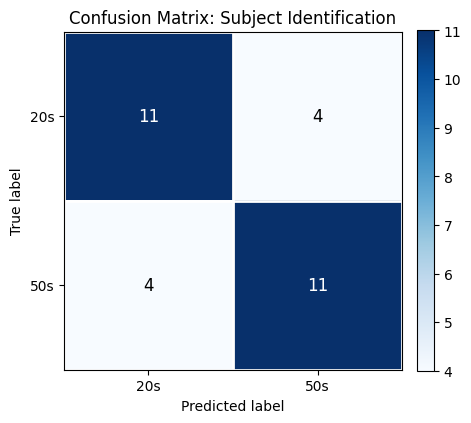

In [ ]:
from sklearn.metrics import confusion_matrix

cm_age = confusion_matrix(y_true_age, y_pred_age)

plot_confusion_matrix(
    cm_age,
    class_names=["20s", "50s"],
    title="Confusion Matrix: Subject Identification"
)


## **사람구분**

In [ ]:
# 사람 ID → class index
SUBJECT_TO_LABEL = {
    "1": 0,
    "2": 1,
    "3": 2,
    "4": 3
}

NUM_CLASSES = 4


In [ ]:
class FileClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = WindowEncoder()

        self.att = nn.Sequential(
            nn.Linear(CH*4, 64),
            nn.Tanh(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, 1)
        )

        self.fc = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(CH*4, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(64, NUM_CLASSES)  # ⭐ 4-class
        )

    def forward(self, x):
        B, N, C, L = x.shape
        x = x.view(B*N, C, L)

        z = self.enc(x)          # (B*N, D)
        z = z.view(B, N, -1)     # (B, N, D)

        a = self.att(z).squeeze(-1)
        w = torch.softmax(a, dim=1)

        z_file = (z * w.unsqueeze(-1)).sum(dim=1)
        return self.fc(z_file)


In [ ]:
@torch.no_grad()
def eval_file_level(model, loader, verbose=False):
    model.eval()
    y_true, y_pred = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        pred = logits.argmax(1).cpu().numpy()

        y_true.extend(yb.numpy())
        y_pred.extend(pred)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")

    if verbose:
        print("ACC:", acc)
        print("macro-F1:", f1)
        print("Confusion matrix (FILE-level):")
        print(confusion_matrix(y_true, y_pred))
        print(classification_report(
            y_true, y_pred,
            target_names=["S1","S2","S3","S4"],
            zero_division=0
        ))

    return acc, f1


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

files_all = files
y_all = [SUBJECT_TO_LABEL[parse_sid_from_folder(f)] for f in files_all]

sss = StratifiedShuffleSplit(
    n_splits=1, test_size=0.3, random_state=42
)

train_idx, test_idx = next(sss.split(files_all, y_all))

FOLDS = [(
    [files_all[i] for i in train_idx],
    [files_all[i] for i in test_idx]
)]


In [ ]:
fold_accs, fold_f1s = [], []

for fold, (tr_files, te_files) in enumerate(FOLDS, 1):
    print(f"\n==================== FOLD {fold} ====================")
    print("train files:", len(tr_files), "test files:", len(te_files))

    # dataset / loader
    tr_ds = PPGFileDataset(tr_files, train=True)
    te_ds = PPGFileDataset(te_files, train=False)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_FILES, shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH_FILES, shuffle=False)

    # ⭐ 이 3개는 반드시 여기 있어야 함
    model = FileClassifier().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

    # early stopping
    best_f1 = -1
    best_state = None
    patience, wait = 10, 0

    for ep in range(1, EPOCHS + 1):
        train_epoch(model, tr_loader, optimizer, criterion)

        acc, f1 = eval_file_level(model, te_loader, verbose=False)

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            wait = 0
            print(f"[Fold {fold}] ep={ep:03d} NEW BEST acc={acc:.3f} f1={f1:.3f}")
            eval_file_level(model, te_loader, verbose=True)
        else:
            wait += 1

        if wait >= patience:
            print(f"[Fold {fold}] early stop at ep={ep}")
            break

    # fold best
    model.load_state_dict(best_state)
    acc, f1 = eval_file_level(model, te_loader, verbose=True)

    fold_accs.append(acc)
    fold_f1s.append(f1)

print("\n==================== FINAL ====================")
print("mean acc:", float(np.mean(fold_accs)))
print("mean f1 :", float(np.mean(fold_f1s)))



==================== FOLD 1 ====================
train files: 42 test files: 18
[Fold 1] ep=001 NEW BEST acc=0.222 f1=0.095
ACC: 0.2222222222222222
macro-F1: 0.09523809523809523
Confusion matrix (FILE-level):
[[0 0 0 5]
 [1 0 0 3]
 [0 0 0 5]
 [0 0 0 4]]
              precision    recall  f1-score   support

          S1       0.00      0.00      0.00         5
          S2       0.00      0.00      0.00         4
          S3       0.00      0.00      0.00         5
          S4       0.24      1.00      0.38         4

    accuracy                           0.22        18
   macro avg       0.06      0.25      0.10        18
weighted avg       0.05      0.22      0.08        18

[Fold 1] ep=002 NEW BEST acc=0.389 f1=0.323
ACC: 0.3888888888888889
macro-F1: 0.32386363636363635
Confusion matrix (FILE-level):
[[3 2 0 0]
 [0 3 0 1]
 [1 2 0 2]
 [3 0 0 1]]
              precision    recall  f1-score   support

          S1       0.43      0.60      0.50         5
          S2       0.43    

In [ ]:
model.load_state_dict(best_state)

y_true_age, y_pred_age = get_file_level_preds(model, te_loader)

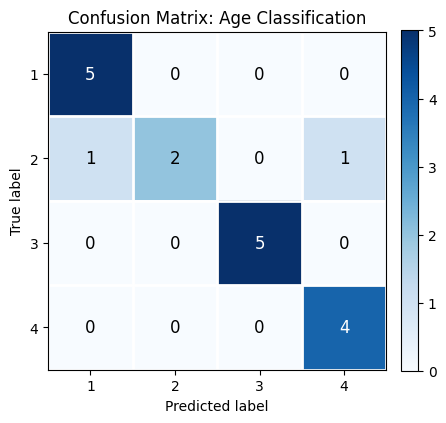

In [ ]:
from sklearn.metrics import confusion_matrix

cm_age = confusion_matrix(y_true_age, y_pred_age)

plot_confusion_matrix(
    cm_age,
    class_names=["1", "2", "3", "4"],
    title="Confusion Matrix: Age Classification"
)


---

In [ ]:
# ============================================
# 0) Imports / 기본 세팅
# ============================================
import os, re, glob, math, random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# ============================================
# 1) 경로 / 태스크 선택
# ============================================
# ✅ 네 드라이브 데이터 폴더로 수정
DATA_ROOT = "/content/drive/MyDrive/학교(AI헬스케어)"  # 예시

# TASK: "age"(20s vs 50s) 또는 "id"(사람 구별 4클래스)
TASK = "age"   # ← 여기만 바꿔도 됨 ("age" or "id")

# 파일 확장자
PATTERN = "**/*.txt"


# ============================================
# 2) 파일 파싱 유틸
# ============================================
def read_ppg_txt(fp):
    """
    txt 라인 예: '2025-12-16 16:55:29.327: 210'
    -> value만 뽑아서 float array로 반환
    """
    vals = []
    with open(fp, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # 마지막 ':' 이후 숫자 추출
            # 혹시 공백/탭 섞여도 안전하게
            m = re.search(r":\s*([-+]?\d+(\.\d+)?)\s*$", line)
            if m:
                vals.append(float(m.group(1)))
            else:
                # 라인 형식이 다르면 숫자만 있는 경우도 대응
                m2 = re.search(r"([-+]?\d+(\.\d+)?)\s*$", line)
                if m2:
                    vals.append(float(m2.group(1)))
    return np.asarray(vals, dtype=np.float32)


def normalize_sid(sid):
    sid = str(sid).strip()
    sid = sid.upper().replace("S", "")
    return sid


def parse_sid_from_path(fp):
    """
    sid 추출을 최대한 robust하게:
    1) 상위 폴더명이 '1','2','3','4' 또는 'S1' 같은 경우
    2) 파일명이 '4_1215(3)_...' 처럼 맨 앞 숫자인 경우
    """
    # 1) 폴더명
    parent = os.path.basename(os.path.dirname(fp))
    parent_n = normalize_sid(parent)
    if parent_n.isdigit():
        return parent_n

    # 2) 파일명 앞 숫자
    base = os.path.basename(fp)
    m = re.match(r"^\s*(\d+)_", base)
    if m:
        return normalize_sid(m.group(1))

    # 3) 파일명 어디든 S1, 1 같은 패턴
    m2 = re.search(r"(S?\d+)", base.upper())
    if m2:
        return normalize_sid(m2.group(1))

    return "UNKNOWN"


# ============================================
# 3) 라벨맵 (연령 / 사람)
# ============================================
# ⚠️ 여기서 네 실제 매핑에 맞게만 맞추면 됨
# - sid "1","2"가 20대, "3","4"가 50대라고 가정
SUBJECT_TO_AGE_LABEL = {"1":0, "2":0, "3":1, "4":1}  # 0=20s, 1=50s
SUBJECT_TO_ID_LABEL  = {"1":0, "2":1, "3":2, "4":3}  # 4명 분류

if TASK == "age":
    LABEL_MAP = SUBJECT_TO_AGE_LABEL
    NUM_CLASSES = 2
    CLASS_NAMES = ["20s", "50s"]
elif TASK == "id":
    LABEL_MAP = SUBJECT_TO_ID_LABEL
    NUM_CLASSES = 4
    CLASS_NAMES = ["S1", "S2", "S3", "S4"]
else:
    raise ValueError("TASK must be 'age' or 'id'")

print("TASK:", TASK, "| NUM_CLASSES:", NUM_CLASSES)


# ============================================
# 4) 윈도우/로더 하이퍼파라미터
# ============================================
WIN_LEN = 300       # window length (샘플 단위)
HOP     = 100       # hop length
N_WINS_PER_FILE = 128  # 파일당 몇 개 윈도우를 배치로 뽑을지
BATCH_FILES = 8

LR = 1e-3
WD = 1e-4
EPOCHS = 30

# 정규화 옵션
USE_ZSCORE = True


# ============================================
# 5) Dataset (✅ __len__ 포함)
# ============================================
def make_windows(x, win_len, hop):
    """1D array x -> (n_win, win_len)"""
    if len(x) < win_len:
        return np.zeros((0, win_len), dtype=np.float32)
    n = 1 + (len(x) - win_len) // hop
    out = np.zeros((n, win_len), dtype=np.float32)
    for i in range(n):
        s = i * hop
        out[i] = x[s:s+win_len]
    return out

class PPGFileDataset(Dataset):
    """
    파일 1개 -> 여러 윈도우 만들고
    (N_WINS_PER_FILE, WIN_LEN) + label 반환

    ✅ __len__ 구현되어 DataLoader 에러 해결
    ✅ 라벨 out-of-range 바로 잡도록 sanity check 포함
    """
    def __init__(self, file_list, train=True):
        self.file_list = list(file_list)
        self.train = train

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fp = self.file_list[idx]
        sid = normalize_sid(parse_sid_from_path(fp))

        if sid not in LABEL_MAP:
            raise ValueError(f"[NO LABEL] sid={sid} fp={fp}")

        y = int(LABEL_MAP[sid])
        if not (0 <= y < NUM_CLASSES):
            raise ValueError(f"[LABEL OOR] y={y}, NUM_CLASSES={NUM_CLASSES}, sid={sid}, fp={fp}")

        x = read_ppg_txt(fp)  # (T,)
        wins = make_windows(x, WIN_LEN, HOP)  # (n_win, WIN_LEN)

        if wins.shape[0] == 0:
            # 너무 짧아서 윈도우 못 만들면 0으로 패딩 1개라도 만들어서 반환
            wins = np.zeros((1, WIN_LEN), dtype=np.float32)

        # z-score (윈도우별)
        if USE_ZSCORE:
            mu = wins.mean(axis=1, keepdims=True)
            sd = wins.std(axis=1, keepdims=True) + 1e-6
            wins = (wins - mu) / sd

        # 파일당 고정 개수 윈도우로 맞추기
        n = wins.shape[0]
        if n >= N_WINS_PER_FILE:
            if self.train:
                sel = np.random.choice(n, N_WINS_PER_FILE, replace=False)
            else:
                # test는 deterministic
                sel = np.linspace(0, n-1, N_WINS_PER_FILE).astype(int)
            wins = wins[sel]
        else:
            # 부족하면 반복/패딩
            if self.train:
                sel = np.random.choice(n, N_WINS_PER_FILE, replace=True)
                wins = wins[sel]
            else:
                pad = np.zeros((N_WINS_PER_FILE - n, WIN_LEN), dtype=np.float32)
                wins = np.concatenate([wins, pad], axis=0)

        X = torch.tensor(wins, dtype=torch.float32)  # (N_WINS, WIN_LEN)
        y = torch.tensor(y, dtype=torch.long)        # scalar

        return X, y


# ============================================
# 6) ResNet1D 모델 (파일단위 pooling 포함)
# ============================================
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, k=7, dropout=0.0):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=k, stride=stride, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=k, stride=1, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        return F.relu(h + self.skip(x))

class ResNet1DWindowEncoder(nn.Module):
    def __init__(self, base_ch=32, blocks=(2,2,2), k=7, dropout=0.0):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, base_ch, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(base_ch),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        ch = base_ch
        layers = []
        for stage_i, n_blocks in enumerate(blocks):
            if stage_i > 0:
                layers.append(ResBlock1D(ch, ch*2, stride=2, k=k, dropout=dropout))
                ch *= 2
                n_blocks -= 1
            for _ in range(n_blocks):
                layers.append(ResBlock1D(ch, ch, stride=1, k=k, dropout=dropout))

        self.body = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.out_dim = ch

    def forward(self, x):          # x: (B,1,L)
        x = self.stem(x)
        x = self.body(x)
        x = self.pool(x).squeeze(-1)  # (B,C)
        return x

class FileClassifierResNet1D(nn.Module):
    """
    입력: (B, N_WINS, WIN_LEN)
    - 윈도우별 embedding -> 파일 pooling -> 분류
    """
    def __init__(self, num_classes, base_ch=32, blocks=(2,2,2), dropout=0.3, pool="attn"):
        super().__init__()
        self.enc = ResNet1DWindowEncoder(base_ch=base_ch, blocks=blocks, dropout=dropout)
        self.pool_type = pool

        if pool == "attn":
            self.att = nn.Sequential(
                nn.Linear(self.enc.out_dim, self.enc.out_dim // 2),
                nn.ReLU(),
                nn.Linear(self.enc.out_dim // 2, 1),
            )

        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(self.enc.out_dim, num_classes)

    def forward(self, x):
        # x: (B,N,L)
        B, N, L = x.shape
        x = x.reshape(B*N, 1, L)
        z = self.enc(x)            # (B*N, D)
        z = z.view(B, N, -1)       # (B, N, D)

        if self.pool_type == "mean":
            z_file = z.mean(dim=1)
        else:
            a = self.att(z).squeeze(-1)      # (B,N)
            w = torch.softmax(a, dim=1)      # (B,N)
            z_file = (z * w.unsqueeze(-1)).sum(dim=1)

        z_file = self.drop(z_file)
        logits = self.fc(z_file)   # (B, num_classes)
        return logits


# ============================================
# 7) Train / Eval (파일단위 acc/f1)
# ============================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)

        # ✅ 여기서 라벨 범위 강제 체크 (또 out-of-bounds 나면 여기서 먼저 잡힘)
        if y.min().item() < 0 or y.max().item() >= NUM_CLASSES:
            raise ValueError(f"Label out of range in batch: min={y.min().item()}, max={y.max().item()}, NUM_CLASSES={NUM_CLASSES}")

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def eval_file_level(model, loader, verbose=True, class_names=None):
    model.eval()
    y_true, y_pred = [], []
    for X, y in loader:
        X = X.to(DEVICE)
        logits = model(X)
        pred = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        y_pred.extend(pred)
        y_true.extend(y.numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")

    if verbose:
        cm = confusion_matrix(y_true, y_pred)
        print("ACC:", acc)
        print("macro-F1:", f1)
        print("Confusion matrix (FILE-level):")
        print(cm)
        if class_names is not None:
            print(classification_report(y_true, y_pred, target_names=class_names, digits=2, zero_division=0))
        else:
            print(classification_report(y_true, y_pred, digits=2, zero_division=0))

    return acc, f1


# ============================================
# 8) 파일 수집 / fold 생성
# ============================================
ALL_FILES = sorted(glob.glob(os.path.join(DATA_ROOT, PATTERN), recursive=True))
ALL_FILES = [f for f in ALL_FILES if os.path.isfile(f)]
print("Total txt files:", len(ALL_FILES))

# 라벨 생성(파일 단위)
y_all = []
valid_files = []
for f in ALL_FILES:
    sid = normalize_sid(parse_sid_from_path(f))
    if sid in LABEL_MAP:
        y_all.append(int(LABEL_MAP[sid]))
        valid_files.append(f)
    else:
        # 라벨 없는 파일은 스킵(예: test 폴더)
        pass

ALL_FILES = valid_files
y_all = np.array(y_all, dtype=int)

print("Labeled files:", len(ALL_FILES))
print("Label counts:", np.bincount(y_all, minlength=NUM_CLASSES))

# 2-fold 예시(네가 원래 하던 느낌)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)
FOLDS = []
for tr_idx, te_idx in skf.split(ALL_FILES, y_all):
    tr_files = [ALL_FILES[i] for i in tr_idx]
    te_files = [ALL_FILES[i] for i in te_idx]
    FOLDS.append((tr_files, te_files))


# ============================================
# 9) Cross-validation 학습
# ============================================
fold_accs, fold_f1s = [], []

for fold, (tr_files, te_files) in enumerate(FOLDS, 1):
    print(f"\n==================== FOLD {fold} ====================")
    print("train files:", len(tr_files), "test files:", len(te_files))

    # 라벨 sanity
    y_tr = [int(LABEL_MAP[normalize_sid(parse_sid_from_path(f))]) for f in tr_files]
    print("train labels unique:", sorted(set(y_tr)))

    tr_ds = PPGFileDataset(tr_files, train=True)
    te_ds = PPGFileDataset(te_files, train=False)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_FILES, shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH_FILES, shuffle=False)

    model = FileClassifierResNet1D(
        num_classes=NUM_CLASSES,
        base_ch=32,
        blocks=(2,2,2),
        dropout=0.3,
        pool="attn"  # "mean"도 가능
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

    best_f1 = -1
    best_state = None
    patience, wait = 10, 0

    for ep in range(1, EPOCHS + 1):
        train_epoch(model, tr_loader, optimizer, criterion)
        acc, f1 = eval_file_level(model, te_loader, verbose=False, class_names=CLASS_NAMES)

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            print(f"[Fold {fold}] ep={ep:03d} NEW BEST acc={acc:.3f} f1={f1:.3f}")
        else:
            wait += 1

        if wait >= patience:
            print(f"[Fold {fold}] early stop at ep={ep}")
            break

    # best load + verbose 평가
    model.load_state_dict(best_state)
    print(f"\n[Fold {fold}] BEST RESULT (final)")
    acc, f1 = eval_file_level(model, te_loader, verbose=True, class_names=CLASS_NAMES)

    fold_accs.append(acc)
    fold_f1s.append(f1)

print("\n==================== FINAL (2-fold mean) ====================")
print("mean acc:", float(np.mean(fold_accs)))
print("mean f1 :", float(np.mean(fold_f1s)))


# ============================================
# 10) Confusion Matrix Plot (글씨 안 짤리게)
# ============================================
def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5.2, 4.8))  # ✅ 약간 키움
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title
    )

    # ✅ 회전 + 여백
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")  # 필요하면 45로 바꿔도 됨

    # 숫자 표시
    thresh = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    fig.tight_layout(pad=1.2)  # ✅ 짤림 방지
    plt.show()


DEVICE: cpu
TASK: age | NUM_CLASSES: 2
Total txt files: 0
Labeled files: 0
Label counts: [0 0]


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
model.load_state_dict(best_state)

y_true_age, y_pred_age = get_file_level_preds(model, te_loader)

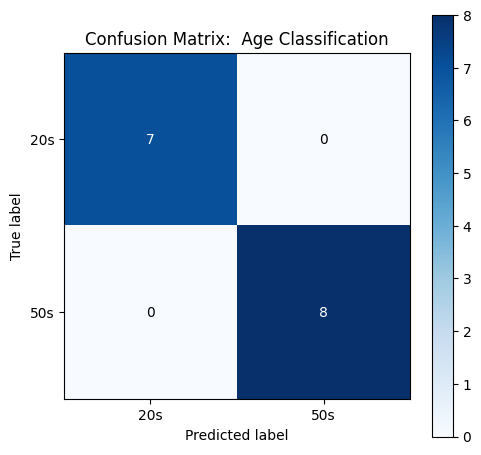

In [ ]:
from sklearn.metrics import confusion_matrix

cm_age = confusion_matrix(y_true_age, y_pred_age)

plot_confusion_matrix(
    cm_age,
    class_names=["20s", "50s"],
    title="Confusion Matrix:  Age Classification"
)


In [ ]:
# ============================================
# 0) Imports / 기본 세팅
# ============================================
import os, re, glob, math, random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# ============================================
# 1) 경로 / 태스크 선택
# ============================================
# ✅ 네 드라이브 데이터 폴더로 수정
DATA_ROOT = "/content/drive/MyDrive/학교(AI헬스케어)"  # 예시

# TASK: "age"(20s vs 50s) 또는 "id"(사람 구별 4클래스)
TASK = "id"   # ← 여기만 바꿔도 됨 ("age" or "id")

# 파일 확장자
PATTERN = "**/*.txt"


# ============================================
# 2) 파일 파싱 유틸
# ============================================
def read_ppg_txt(fp):
    """
    txt 라인 예: '2025-12-16 16:55:29.327: 210'
    -> value만 뽑아서 float array로 반환
    """
    vals = []
    with open(fp, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # 마지막 ':' 이후 숫자 추출
            # 혹시 공백/탭 섞여도 안전하게
            m = re.search(r":\s*([-+]?\d+(\.\d+)?)\s*$", line)
            if m:
                vals.append(float(m.group(1)))
            else:
                # 라인 형식이 다르면 숫자만 있는 경우도 대응
                m2 = re.search(r"([-+]?\d+(\.\d+)?)\s*$", line)
                if m2:
                    vals.append(float(m2.group(1)))
    return np.asarray(vals, dtype=np.float32)


def normalize_sid(sid):
    sid = str(sid).strip()
    sid = sid.upper().replace("S", "")
    return sid


def parse_sid_from_path(fp):
    """
    sid 추출을 최대한 robust하게:
    1) 상위 폴더명이 '1','2','3','4' 또는 'S1' 같은 경우
    2) 파일명이 '4_1215(3)_...' 처럼 맨 앞 숫자인 경우
    """
    # 1) 폴더명
    parent = os.path.basename(os.path.dirname(fp))
    parent_n = normalize_sid(parent)
    if parent_n.isdigit():
        return parent_n

    # 2) 파일명 앞 숫자
    base = os.path.basename(fp)
    m = re.match(r"^\s*(\d+)_", base)
    if m:
        return normalize_sid(m.group(1))

    # 3) 파일명 어디든 S1, 1 같은 패턴
    m2 = re.search(r"(S?\d+)", base.upper())
    if m2:
        return normalize_sid(m2.group(1))

    return "UNKNOWN"


# ============================================
# 3) 라벨맵 (연령 / 사람)
# ============================================
# ⚠️ 여기서 네 실제 매핑에 맞게만 맞추면 됨
# - sid "1","2"가 20대, "3","4"가 50대라고 가정
SUBJECT_TO_AGE_LABEL = {"1":0, "2":0, "3":1, "4":1}  # 0=20s, 1=50s
SUBJECT_TO_ID_LABEL  = {"1":0, "2":1, "3":2, "4":3}  # 4명 분류

if TASK == "age":
    LABEL_MAP = SUBJECT_TO_AGE_LABEL
    NUM_CLASSES = 2
    CLASS_NAMES = ["20s", "50s"]
elif TASK == "id":
    LABEL_MAP = SUBJECT_TO_ID_LABEL
    NUM_CLASSES = 4
    CLASS_NAMES = ["S1", "S2", "S3", "S4"]
else:
    raise ValueError("TASK must be 'age' or 'id'")

print("TASK:", TASK, "| NUM_CLASSES:", NUM_CLASSES)


# ============================================
# 4) 윈도우/로더 하이퍼파라미터
# ============================================
WIN_LEN = 300       # window length (샘플 단위)
HOP     = 100       # hop length
N_WINS_PER_FILE = 128 # 파일당 몇 개 윈도우를 배치로 뽑을지
BATCH_FILES = 8

LR = 1e-3
WD = 1e-4
EPOCHS = 300

# 정규화 옵션
USE_ZSCORE = True


# ============================================
# 5) Dataset (✅ __len__ 포함)
# ============================================
def make_windows(x, win_len, hop):
    """1D array x -> (n_win, win_len)"""
    if len(x) < win_len:
        return np.zeros((0, win_len), dtype=np.float32)
    n = 1 + (len(x) - win_len) // hop
    out = np.zeros((n, win_len), dtype=np.float32)
    for i in range(n):
        s = i * hop
        out[i] = x[s:s+win_len]
    return out

class PPGFileDataset(Dataset):
    """
    파일 1개 -> 여러 윈도우 만들고
    (N_WINS_PER_FILE, WIN_LEN) + label 반환

    ✅ __len__ 구현되어 DataLoader 에러 해결
    ✅ 라벨 out-of-range 바로 잡도록 sanity check 포함
    """
    def __init__(self, file_list, train=True):
        self.file_list = list(file_list)
        self.train = train

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fp = self.file_list[idx]
        sid = normalize_sid(parse_sid_from_path(fp))

        if sid not in LABEL_MAP:
            raise ValueError(f"[NO LABEL] sid={sid} fp={fp}")

        y = int(LABEL_MAP[sid])
        if not (0 <= y < NUM_CLASSES):
            raise ValueError(f"[LABEL OOR] y={y}, NUM_CLASSES={NUM_CLASSES}, sid={sid}, fp={fp}")

        x = read_ppg_txt(fp)  # (T,)
        wins = make_windows(x, WIN_LEN, HOP)  # (n_win, WIN_LEN)

        if wins.shape[0] == 0:
            # 너무 짧아서 윈도우 못 만들면 0으로 패딩 1개라도 만들어서 반환
            wins = np.zeros((1, WIN_LEN), dtype=np.float32)

        # z-score (윈도우별)
        if USE_ZSCORE:
            mu = wins.mean(axis=1, keepdims=True)
            sd = wins.std(axis=1, keepdims=True) + 1e-6
            wins = (wins - mu) / sd

        # 파일당 고정 개수 윈도우로 맞추기
        n = wins.shape[0]
        if n >= N_WINS_PER_FILE:
            if self.train:
                sel = np.random.choice(n, N_WINS_PER_FILE, replace=False)
            else:
                # test는 deterministic
                sel = np.linspace(0, n-1, N_WINS_PER_FILE).astype(int)
            wins = wins[sel]
        else:
            # 부족하면 반복/패딩
            if self.train:
                sel = np.random.choice(n, N_WINS_PER_FILE, replace=True)
                wins = wins[sel]
            else:
                pad = np.zeros((N_WINS_PER_FILE - n, WIN_LEN), dtype=np.float32)
                wins = np.concatenate([wins, pad], axis=0)

        X = torch.tensor(wins, dtype=torch.float32)  # (N_WINS, WIN_LEN)
        y = torch.tensor(y, dtype=torch.long)        # scalar

        return X, y


# ============================================
# 6) ResNet1D 모델 (파일단위 pooling 포함)
# ============================================
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, k=7, dropout=0.0):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=k, stride=stride, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=k, stride=1, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        return F.relu(h + self.skip(x))

class ResNet1DWindowEncoder(nn.Module):
    def __init__(self, base_ch=32, blocks=(2,2,2), k=7, dropout=0.0):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, base_ch, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(base_ch),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        ch = base_ch
        layers = []
        for stage_i, n_blocks in enumerate(blocks):
            if stage_i > 0:
                layers.append(ResBlock1D(ch, ch*2, stride=2, k=k, dropout=dropout))
                ch *= 2
                n_blocks -= 1
            for _ in range(n_blocks):
                layers.append(ResBlock1D(ch, ch, stride=1, k=k, dropout=dropout))

        self.body = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.out_dim = ch

    def forward(self, x):          # x: (B,1,L)
        x = self.stem(x)
        x = self.body(x)
        x = self.pool(x).squeeze(-1)  # (B,C)
        return x

class FileClassifierResNet1D(nn.Module):
    """
    입력: (B, N_WINS, WIN_LEN)
    - 윈도우별 embedding -> 파일 pooling -> 분류
    """
    def __init__(self, num_classes, base_ch=32, blocks=(2,2,2), dropout=0.3, pool="attn"):
        super().__init__()
        self.enc = ResNet1DWindowEncoder(base_ch=base_ch, blocks=blocks, dropout=dropout)
        self.pool_type = pool

        if pool == "attn":
            self.att = nn.Sequential(
                nn.Linear(self.enc.out_dim, self.enc.out_dim // 2),
                nn.ReLU(),
                nn.Linear(self.enc.out_dim // 2, 1),
            )

        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(self.enc.out_dim, num_classes)

    def forward(self, x):
        # x: (B,N,L)
        B, N, L = x.shape
        x = x.reshape(B*N, 1, L)
        z = self.enc(x)            # (B*N, D)
        z = z.view(B, N, -1)       # (B, N, D)

        if self.pool_type == "mean":
            z_file = z.mean(dim=1)
        else:
            a = self.att(z).squeeze(-1)      # (B,N)
            w = torch.softmax(a, dim=1)      # (B,N)
            z_file = (z * w.unsqueeze(-1)).sum(dim=1)

        z_file = self.drop(z_file)
        logits = self.fc(z_file)   # (B, num_classes)
        return logits


# ============================================
# 7) Train / Eval (파일단위 acc/f1)
# ============================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)

        # ✅ 여기서 라벨 범위 강제 체크 (또 out-of-bounds 나면 여기서 먼저 잡힘)
        if y.min().item() < 0 or y.max().item() >= NUM_CLASSES:
            raise ValueError(f"Label out of range in batch: min={y.min().item()}, max={y.max().item()}, NUM_CLASSES={NUM_CLASSES}")

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def eval_file_level(model, loader, verbose=True, class_names=None):
    model.eval()
    y_true, y_pred = [], []
    for X, y in loader:
        X = X.to(DEVICE)
        logits = model(X)
        pred = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        y_pred.extend(pred)
        y_true.extend(y.numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")

    if verbose:
        cm = confusion_matrix(y_true, y_pred)
        print("ACC:", acc)
        print("macro-F1:", f1)
        print("Confusion matrix (FILE-level):")
        print(cm)
        if class_names is not None:
            print(classification_report(y_true, y_pred, target_names=class_names, digits=2, zero_division=0))
        else:
            print(classification_report(y_true, y_pred, digits=2, zero_division=0))

    return acc, f1


# ============================================
# 8) 파일 수집 / fold 생성
# ============================================
ALL_FILES = sorted(glob.glob(os.path.join(DATA_ROOT, PATTERN), recursive=True))
ALL_FILES = [f for f in ALL_FILES if os.path.isfile(f)]
print("Total txt files:", len(ALL_FILES))

# 라벨 생성(파일 단위)
y_all = []
valid_files = []
for f in ALL_FILES:
    sid = normalize_sid(parse_sid_from_path(f))
    if sid in LABEL_MAP:
        y_all.append(int(LABEL_MAP[sid]))
        valid_files.append(f)
    else:
        # 라벨 없는 파일은 스킵(예: test 폴더)
        pass

ALL_FILES = valid_files
y_all = np.array(y_all, dtype=int)

print("Labeled files:", len(ALL_FILES))
print("Label counts:", np.bincount(y_all, minlength=NUM_CLASSES))

# 2-fold 예시(네가 원래 하던 느낌)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)
FOLDS = []
for tr_idx, te_idx in skf.split(ALL_FILES, y_all):
    tr_files = [ALL_FILES[i] for i in tr_idx]
    te_files = [ALL_FILES[i] for i in te_idx]
    FOLDS.append((tr_files, te_files))


# ============================================
# 9) Cross-validation 학습
# ============================================
fold_accs, fold_f1s = [], []

for fold, (tr_files, te_files) in enumerate(FOLDS, 1):
    print(f"\n==================== FOLD {fold} ====================")
    print("train files:", len(tr_files), "test files:", len(te_files))

    # 라벨 sanity
    y_tr = [int(LABEL_MAP[normalize_sid(parse_sid_from_path(f))]) for f in tr_files]
    print("train labels unique:", sorted(set(y_tr)))

    tr_ds = PPGFileDataset(tr_files, train=True)
    te_ds = PPGFileDataset(te_files, train=False)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_FILES, shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH_FILES, shuffle=False)

    model = FileClassifierResNet1D(
        num_classes=NUM_CLASSES,
        base_ch=32,
        blocks=(2,2,2),
        dropout=0.3,
        pool="attn"  # "mean"도 가능
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

    best_f1 = -1
    best_state = None
    patience, wait = 10, 0

    for ep in range(1, EPOCHS + 1):
        train_epoch(model, tr_loader, optimizer, criterion)
        acc, f1 = eval_file_level(model, te_loader, verbose=False, class_names=CLASS_NAMES)

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            print(f"[Fold {fold}] ep={ep:03d} NEW BEST acc={acc:.3f} f1={f1:.3f}")
        else:
            wait += 1

        if wait >= patience:
            print(f"[Fold {fold}] early stop at ep={ep}")
            break

    # best load + verbose 평가
    model.load_state_dict(best_state)
    print(f"\n[Fold {fold}] BEST RESULT (final)")
    acc, f1 = eval_file_level(model, te_loader, verbose=True, class_names=CLASS_NAMES)

    fold_accs.append(acc)
    fold_f1s.append(f1)

print("\n==================== FINAL (2-fold mean) ====================")
print("mean acc:", float(np.mean(fold_accs)))
print("mean f1 :", float(np.mean(fold_f1s)))


# ============================================
# 10) Confusion Matrix Plot (글씨 안 짤리게)
# ============================================
def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5.2, 4.8))  # ✅ 약간 키움
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title
    )

    # ✅ 회전 + 여백
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")  # 필요하면 45로 바꿔도 됨

    # 숫자 표시
    thresh = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    fig.tight_layout(pad=1.2)  # ✅ 짤림 방지
    plt.show()


DEVICE: cuda
TASK: id | NUM_CLASSES: 4
Total txt files: 60
Labeled files: 60
Label counts: [15 15 15 15]

==================== FOLD 1 ====================
train files: 45 test files: 15
train labels unique: [0, 1, 2, 3]
[Fold 1] ep=001 NEW BEST acc=0.267 f1=0.105
[Fold 1] ep=002 NEW BEST acc=0.267 f1=0.118
[Fold 1] ep=003 NEW BEST acc=0.667 f1=0.604
[Fold 1] ep=004 NEW BEST acc=0.667 f1=0.658
[Fold 1] ep=006 NEW BEST acc=0.667 f1=0.664
[Fold 1] ep=008 NEW BEST acc=0.667 f1=0.680
[Fold 1] ep=009 NEW BEST acc=0.800 f1=0.810
[Fold 1] ep=015 NEW BEST acc=0.867 f1=0.861
[Fold 1] ep=016 NEW BEST acc=0.867 f1=0.867
[Fold 1] ep=018 NEW BEST acc=0.933 f1=0.929
[Fold 1] ep=019 NEW BEST acc=0.933 f1=0.937
[Fold 1] early stop at ep=29

[Fold 1] BEST RESULT (final)
ACC: 0.9333333333333333
macro-F1: 0.9365079365079365
Confusion matrix (FILE-level):
[[3 0 1 0]
 [0 4 0 0]
 [0 0 4 0]
 [0 0 0 3]]
              precision    recall  f1-score   support

          S1       1.00      0.75      0.86         4

In [ ]:
model.load_state_dict(best_state)

y_true_age, y_pred_age = get_file_level_preds(model, te_loader)

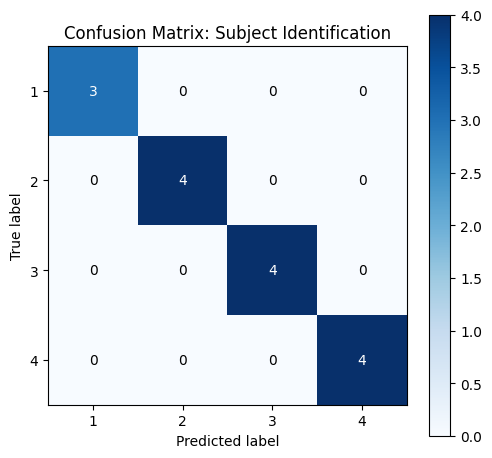

In [ ]:
from sklearn.metrics import confusion_matrix

cm_age = confusion_matrix(y_true_age, y_pred_age)

plot_confusion_matrix(
    cm_age,
    class_names=["1", "2", "3", "4"],
    title="Confusion Matrix: Subject Identification"
)


In [ ]:
# ============================================
# 0) Imports / 기본 세팅
# ============================================
import os, re, glob, math, random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


# ============================================
# 1) 경로 / 태스크 선택
# ============================================
DATA_ROOT = "/content/drive/MyDrive/학교(AI헬스케어)"  # 예시

TASK = "age"   # ("age" or "id")
PATTERN = "**/*.txt"


# ============================================
# 2) 파일 파싱 유틸
# ============================================
def read_ppg_txt(fp):
    """
    txt 라인 예: '2025-12-16 16:55:29.327: 210'
    -> value만 뽑아서 float array로 반환
    """
    vals = []
    with open(fp, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            m = re.search(r":\s*([-+]?\d+(\.\d+)?)\s*$", line)
            if m:
                vals.append(float(m.group(1)))
            else:
                m2 = re.search(r"([-+]?\d+(\.\d+)?)\s*$", line)
                if m2:
                    vals.append(float(m2.group(1)))
    return np.asarray(vals, dtype=np.float32)


def normalize_sid(sid):
    sid = str(sid).strip()
    sid = sid.upper().replace("S", "")
    return sid


def parse_sid_from_path(fp):
    """
    sid 추출을 최대한 robust하게:
    1) 상위 폴더명이 '1','2','3','4' 또는 'S1' 같은 경우
    2) 파일명이 '4_1215(3)_...' 처럼 맨 앞 숫자인 경우
    """
    parent = os.path.basename(os.path.dirname(fp))
    parent_n = normalize_sid(parent)
    if parent_n.isdigit():
        return parent_n

    base = os.path.basename(fp)
    m = re.match(r"^\s*(\d+)_", base)
    if m:
        return normalize_sid(m.group(1))

    m2 = re.search(r"(S?\d+)", base.upper())
    if m2:
        return normalize_sid(m2.group(1))

    return "UNKNOWN"


# ============================================
# ✅ (추가) 2-1) 필터링 함수 (baseline 제거 + smoothing)
# ============================================
def detrend_moving_average(x, ma=301):
    """
    이동평균으로 baseline(드리프트) 제거: y = x - MA(x)
    - fs 몰라도 동작
    - ma는 홀수 권장
    """
    x = np.asarray(x, dtype=np.float32)
    if ma <= 1 or len(x) < ma:
        return x
    if ma % 2 == 0:
        ma += 1

    pad = ma // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    kernel = np.ones(ma, dtype=np.float32) / ma
    trend = np.convolve(xp, kernel, mode="valid")
    return (x - trend).astype(np.float32)


def smooth_moving_average(x, ma=5):
    """
    약한 스무딩(고주파 노이즈 완화): MA(x)
    """
    x = np.asarray(x, dtype=np.float32)
    if ma <= 1 or len(x) < ma:
        return x

    pad = ma // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    kernel = np.ones(ma, dtype=np.float32) / ma
    y = np.convolve(xp, kernel, mode="valid")
    return y.astype(np.float32)


# ============================================
# 3) 라벨맵 (연령 / 사람)
# ============================================
SUBJECT_TO_AGE_LABEL = {"1":0, "2":0, "3":1, "4":1}  # 0=20s, 1=50s
SUBJECT_TO_ID_LABEL  = {"1":0, "2":1, "3":2, "4":3}  # 4명 분류

if TASK == "age":
    LABEL_MAP = SUBJECT_TO_AGE_LABEL
    NUM_CLASSES = 2
    CLASS_NAMES = ["20s", "50s"]
elif TASK == "id":
    LABEL_MAP = SUBJECT_TO_ID_LABEL
    NUM_CLASSES = 4
    CLASS_NAMES = ["S1", "S2", "S3", "S4"]
else:
    raise ValueError("TASK must be 'age' or 'id'")

print("TASK:", TASK, "| NUM_CLASSES:", NUM_CLASSES)


# ============================================
# 4) 윈도우/로더 하이퍼파라미터
# ============================================
WIN_LEN = 300
HOP     = 100
N_WINS_PER_FILE = 128
BATCH_FILES = 8

LR = 1e-3
WD = 1e-4
EPOCHS = 30

USE_ZSCORE = True

# ✅ (추가) 필터 하이퍼파라미터 (원하면 여기만 조절)
USE_FILTER = True
BASELINE_MA = 301   # baseline 제거 강도(크게)
SMOOTH_MA   = 5     # 스무딩 강도(작게)


# ============================================
# 5) Dataset (✅ __len__ 포함)
# ============================================
def make_windows(x, win_len, hop):
    if len(x) < win_len:
        return np.zeros((0, win_len), dtype=np.float32)
    n = 1 + (len(x) - win_len) // hop
    out = np.zeros((n, win_len), dtype=np.float32)
    for i in range(n):
        s = i * hop
        out[i] = x[s:s+win_len]
    return out


class PPGFileDataset(Dataset):
    def __init__(self, file_list, train=True):
        self.file_list = list(file_list)
        self.train = train

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fp = self.file_list[idx]
        sid = normalize_sid(parse_sid_from_path(fp))

        if sid not in LABEL_MAP:
            raise ValueError(f"[NO LABEL] sid={sid} fp={fp}")

        y = int(LABEL_MAP[sid])
        if not (0 <= y < NUM_CLASSES):
            raise ValueError(f"[LABEL OOR] y={y}, NUM_CLASSES={NUM_CLASSES}, sid={sid}, fp={fp}")

        x = read_ppg_txt(fp)  # (T,)

        # ============================================
        # ✅✅✅ (추가) 여기서 "필터링" 딱 2줄만 적용
        # ============================================
        if USE_FILTER:
            x = detrend_moving_average(x, ma=BASELINE_MA)
            x = smooth_moving_average(x, ma=SMOOTH_MA)

        wins = make_windows(x, WIN_LEN, HOP)

        if wins.shape[0] == 0:
            wins = np.zeros((1, WIN_LEN), dtype=np.float32)

        if USE_ZSCORE:
            mu = wins.mean(axis=1, keepdims=True)
            sd = wins.std(axis=1, keepdims=True) + 1e-6
            wins = (wins - mu) / sd

        n = wins.shape[0]
        if n >= N_WINS_PER_FILE:
            if self.train:
                sel = np.random.choice(n, N_WINS_PER_FILE, replace=False)
            else:
                sel = np.linspace(0, n-1, N_WINS_PER_FILE).astype(int)
            wins = wins[sel]
        else:
            if self.train:
                sel = np.random.choice(n, N_WINS_PER_FILE, replace=True)
                wins = wins[sel]
            else:
                pad = np.zeros((N_WINS_PER_FILE - n, WIN_LEN), dtype=np.float32)
                wins = np.concatenate([wins, pad], axis=0)

        X = torch.tensor(wins, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)
        return X, y


# ============================================
# 6) ResNet1D 모델 (파일단위 pooling 포함)
# ============================================
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, k=7, dropout=0.0):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=k, stride=stride, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=k, stride=1, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.drop(h)
        h = self.bn2(self.conv2(h))
        return F.relu(h + self.skip(x))


class ResNet1DWindowEncoder(nn.Module):
    def __init__(self, base_ch=32, blocks=(2,2,2), k=7, dropout=0.0):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, base_ch, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(base_ch),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        ch = base_ch
        layers = []
        for stage_i, n_blocks in enumerate(blocks):
            if stage_i > 0:
                layers.append(ResBlock1D(ch, ch*2, stride=2, k=k, dropout=dropout))
                ch *= 2
                n_blocks -= 1
            for _ in range(n_blocks):
                layers.append(ResBlock1D(ch, ch, stride=1, k=k, dropout=dropout))

        self.body = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.out_dim = ch

    def forward(self, x):          # x: (B,1,L)
        x = self.stem(x)
        x = self.body(x)
        x = self.pool(x).squeeze(-1)  # (B,C)
        return x


class FileClassifierResNet1D(nn.Module):
    def __init__(self, num_classes, base_ch=32, blocks=(2,2,2), dropout=0.3, pool="attn"):
        super().__init__()
        self.enc = ResNet1DWindowEncoder(base_ch=base_ch, blocks=blocks, dropout=dropout)
        self.pool_type = pool

        if pool == "attn":
            self.att = nn.Sequential(
                nn.Linear(self.enc.out_dim, self.enc.out_dim // 2),
                nn.ReLU(),
                nn.Linear(self.enc.out_dim // 2, 1),
            )

        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(self.enc.out_dim, num_classes)

    def forward(self, x):
        B, N, L = x.shape
        x = x.reshape(B*N, 1, L)
        z = self.enc(x)
        z = z.view(B, N, -1)

        if self.pool_type == "mean":
            z_file = z.mean(dim=1)
        else:
            a = self.att(z).squeeze(-1)
            w = torch.softmax(a, dim=1)
            z_file = (z * w.unsqueeze(-1)).sum(dim=1)

        z_file = self.drop(z_file)
        logits = self.fc(z_file)
        return logits


# ============================================
# 7) Train / Eval (파일단위 acc/f1)
# ============================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)

        if y.min().item() < 0 or y.max().item() >= NUM_CLASSES:
            raise ValueError(f"Label out of range in batch: min={y.min().item()}, max={y.max().item()}, NUM_CLASSES={NUM_CLASSES}")

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def eval_file_level(model, loader, verbose=True, class_names=None):
    model.eval()
    y_true, y_pred = [], []
    for X, y in loader:
        X = X.to(DEVICE)
        logits = model(X)
        pred = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        y_pred.extend(pred)
        y_true.extend(y.numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")

    if verbose:
        cm = confusion_matrix(y_true, y_pred)
        print("ACC:", acc)
        print("macro-F1:", f1)
        print("Confusion matrix (FILE-level):")
        print(cm)
        if class_names is not None:
            print(classification_report(y_true, y_pred, target_names=class_names, digits=2, zero_division=0))
        else:
            print(classification_report(y_true, y_pred, digits=2, zero_division=0))

    return acc, f1


# ============================================
# 8) 파일 수집 / fold 생성
# ============================================
ALL_FILES = sorted(glob.glob(os.path.join(DATA_ROOT, PATTERN), recursive=True))
ALL_FILES = [f for f in ALL_FILES if os.path.isfile(f)]
print("Total txt files:", len(ALL_FILES))

y_all = []
valid_files = []
for f in ALL_FILES:
    sid = normalize_sid(parse_sid_from_path(f))
    if sid in LABEL_MAP:
        y_all.append(int(LABEL_MAP[sid]))
        valid_files.append(f)

ALL_FILES = valid_files
y_all = np.array(y_all, dtype=int)

print("Labeled files:", len(ALL_FILES))
print("Label counts:", np.bincount(y_all, minlength=NUM_CLASSES))

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)
FOLDS = []
for tr_idx, te_idx in skf.split(ALL_FILES, y_all):
    tr_files = [ALL_FILES[i] for i in tr_idx]
    te_files = [ALL_FILES[i] for i in te_idx]
    FOLDS.append((tr_files, te_files))


# ============================================
# 9) Cross-validation 학습
# ============================================
fold_accs, fold_f1s = [], []

for fold, (tr_files, te_files) in enumerate(FOLDS, 1):
    print(f"\n==================== FOLD {fold} ====================")
    print("train files:", len(tr_files), "test files:", len(te_files))

    y_tr = [int(LABEL_MAP[normalize_sid(parse_sid_from_path(f))]) for f in tr_files]
    print("train labels unique:", sorted(set(y_tr)))

    tr_ds = PPGFileDataset(tr_files, train=True)
    te_ds = PPGFileDataset(te_files, train=False)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_FILES, shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=BATCH_FILES, shuffle=False)

    model = FileClassifierResNet1D(
        num_classes=NUM_CLASSES,
        base_ch=32,
        blocks=(2,2,2),
        dropout=0.3,
        pool="attn"
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

    best_f1 = -1
    best_state = None
    patience, wait = 10, 0

    for ep in range(1, EPOCHS + 1):
        train_epoch(model, tr_loader, optimizer, criterion)
        acc, f1 = eval_file_level(model, te_loader, verbose=False, class_names=CLASS_NAMES)

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            print(f"[Fold {fold}] ep={ep:03d} NEW BEST acc={acc:.3f} f1={f1:.3f}")
        else:
            wait += 1

        if wait >= patience:
            print(f"[Fold {fold}] early stop at ep={ep}")
            break

    model.load_state_dict(best_state)
    print(f"\n[Fold {fold}] BEST RESULT (final)")
    acc, f1 = eval_file_level(model, te_loader, verbose=True, class_names=CLASS_NAMES)

    fold_accs.append(acc)
    fold_f1s.append(f1)

print("\n==================== FINAL (4-fold mean) ====================")
print("mean acc:", float(np.mean(fold_accs)))
print("mean f1 :", float(np.mean(fold_f1s)))


# ============================================
# 10) Confusion Matrix Plot (글씨 안 짤리게)
# ============================================
def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5.2, 4.8))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title
    )

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    thresh = cm.max() / 2.0 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    fig.tight_layout(pad=1.2)
    plt.show()


DEVICE: cpu
TASK: age | NUM_CLASSES: 2
Total txt files: 0
Labeled files: 0
Label counts: [0 0]


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.